# ORB — Implementation Comparison

Loads standardized signal trades from `results/orb_trades.csv` and tests
multiple sizing implementations.

**Implementations:**
1. Simple flat bet (85%)
2. Risk-based (1% risk) across leverage levels (1×, 2×, 4×, 8×, 12×)
3. Rolling Kelly (full, half, quarter)
4. Volatility targeting (10% annualized)

**Key insight:** Risk-based sizing only activates at higher leverage.
At 1× the capital cap overrides the risk formula, making it equivalent to
a simple 100% bet. The ATR-based variable sizing — where tight stops get
larger positions — only emerges when leverage allows the risk formula to
determine position size instead of the capital cap.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _shared.implementations import (
    simple_bet, risk_based, kelly_sizing, vol_targeting, compare_implementations
)

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "ORB"

pd.set_option("display.max_columns", None)

## 2. Load Signal Trades

In [2]:
trades = pd.read_csv("results/orb_trades.csv", parse_dates=["entry_time", "exit_time"])
print(f"Loaded {len(trades)} trades")
print(f"Period: {trades['entry_time'].iloc[0].date()} → {trades['exit_time'].iloc[-1].date()}")
print(f"Columns: {list(trades.columns)}")

Loaded 2333 trades
Period: 2016-01-26 → 2026-03-31
Columns: ['entry_time', 'exit_time', 'direction', 'instrument', 'entry_price', 'exit_price', 'pct_return_gross', 'exit_reason', 'stop_price']


## 3. Sizing Comparison (No Leverage)

All implementations at 1× leverage for apples-to-apples comparison.

In [3]:
# ── Simple bet ────────────────────────────────────────────────────────────────
r_simple = simple_bet(trades, bet_size=0.85)

# ── Risk-based (1× — cap binding, same as simple 100%) ──────────────────────
r_risk_1x = risk_based(trades, risk_pct=0.01, leverage=1)

# ── Kelly variants ────────────────────────────────────────────────────────────
r_kelly_full    = kelly_sizing(trades, fraction=1.0, burn_in=100)
r_kelly_half    = kelly_sizing(trades, fraction=0.5, burn_in=100)
r_kelly_quarter = kelly_sizing(trades, fraction=0.25, burn_in=100)

# ── Vol targeting ─────────────────────────────────────────────────────────────
r_vol = vol_targeting(trades, target_vol=0.10, lookback=60)

base_results = [r_simple, r_risk_1x, r_kelly_full, r_kelly_half, r_kelly_quarter, r_vol]

print("ALL IMPLEMENTATIONS (1× leverage):")
compare_implementations(base_results)

ALL IMPLEMENTATIONS (1× leverage):

Implementation                      Return       CAGR       Sharpe     Sortino    MaxDD      WinRate    PF        
Simple (85% bet)                        53.6%      4.7%      0.89      9.53      -7.5%     11.2%     1.26
Risk-based (1% risk, 1× lev)            65.2%      5.6%      0.89      9.53      -8.8%     11.2%     1.26
Full Kelly (burn-in=100)                 1.3%      0.1%      0.77      6.66      -0.2%     11.2%     1.23
Half Kelly (burn-in=100)                 0.8%      0.1%      0.86      7.57      -0.2%     11.2%     1.26
Quarter Kelly (burn-in=100)              0.5%      0.1%      0.96      8.05      -0.1%     11.2%     1.32
Vol target (10% ann, lookback=60)       80.8%      6.6%      0.84      9.24     -11.3%     11.2%     1.25


## 4. Risk-Based Leverage Sweep

This is where risk-based sizing becomes meaningful. At higher leverage,
the risk formula can actually size trades according to their stop distance
instead of being capped by available capital.

At 1× every trade buys `equity / price` shares (capital constrained).
At 8×+ trades with tight stops get much larger positions — the ATR-based
edge activates.

In [4]:
LEVERAGE_LEVELS = [1, 2, 4, 8, 12]

leverage_results = []
for lev in LEVERAGE_LEVELS:
    r = risk_based(trades, risk_pct=0.01, leverage=lev)
    leverage_results.append(r)

print("RISK-BASED — LEVERAGE SWEEP:")
compare_implementations(leverage_results)

RISK-BASED — LEVERAGE SWEEP:

Implementation                      Return       CAGR       Sharpe     Sortino    MaxDD      WinRate    PF        
Risk-based (1% risk, 1× lev)            65.2%      5.6%      0.89      9.53      -8.8%     11.2%     1.26
Risk-based (1% risk, 2× lev)           163.5%     11.0%      0.89      9.53     -17.0%     11.2%     1.26
Risk-based (1% risk, 4× lev)           517.6%     21.7%      0.90     10.00     -31.5%     11.2%     1.27
Risk-based (1% risk, 8× lev)          2282.0%     40.8%      0.94     13.36     -52.7%     11.2%     1.28
Risk-based (1% risk, 12× lev)         6152.5%     56.3%      1.00     25.82     -60.8%     11.2%     1.29


## 5. Equity Curves — Leverage Sweep

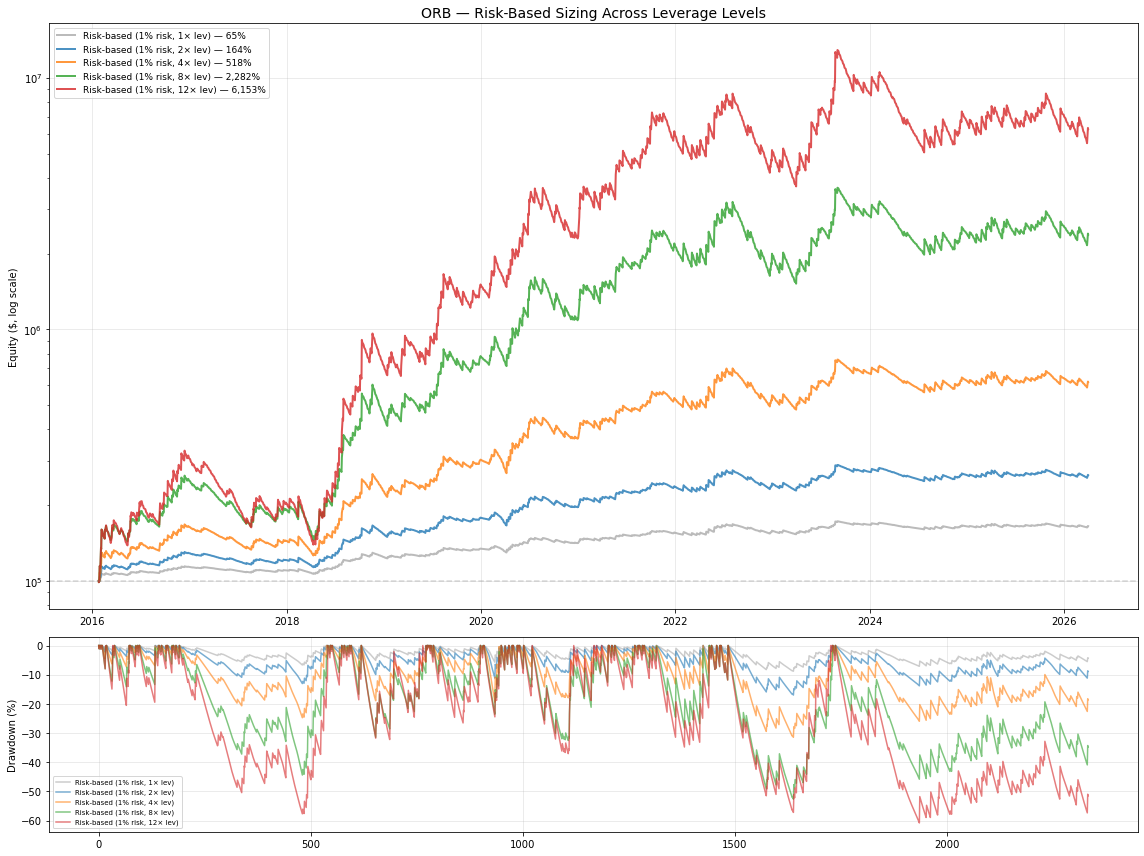

In [5]:
dates = [trades["entry_time"].iloc[0]] + trades["exit_time"].tolist()

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
colors = ["#aaaaaa", "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for r, c in zip(leverage_results, colors):
    eq = r["equity_curve"]
    ret = (eq[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(dates[:len(eq)], eq, linewidth=2, color=c, alpha=0.8,
            label=f"{r['label']} — {ret:,.0f}%")

ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} — Risk-Based Sizing Across Leverage Levels", fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($, log scale)")

# Drawdown
for r, c in zip(leverage_results, colors):
    eq = np.array(r["equity_curve"])
    rm = np.maximum.accumulate(eq)
    dd = (eq - rm) / rm * 100
    axes[1].plot(range(len(dd)), dd, linewidth=1.5, color=c, alpha=0.6, label=r["label"])

axes[1].set_ylabel("Drawdown (%)"); axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6. All Models Equity Curves

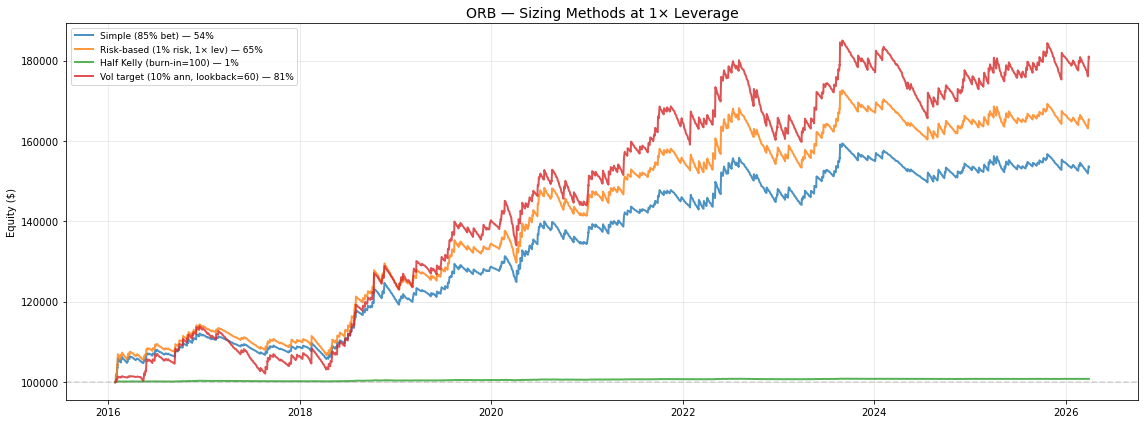

In [8]:
# One of each category (all at 1× leverage)
all_compare = [r_simple, r_risk_1x, r_kelly_half, r_vol]

fig, ax = plt.subplots(figsize=(16, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for r, c in zip(all_compare, colors):
    eq = r["equity_curve"]
    ret = (eq[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(dates[:len(eq)], eq, linewidth=2, color=c, alpha=0.8,
            label=f"{r['label']} — {ret:,.0f}%")

ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} — Sizing Methods at 1× Leverage", fontsize=14)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

## 8. Save Implementation Stats

In [9]:
import json

impl_summary = {}

# Save all base models
for r in base_results:
    key = r["label"].lower().replace(" ", "_").replace("(", "").replace(")", "").replace("%", "pct").replace("=", "").replace(",", "")
    impl_summary[key] = r["stats"]
    impl_summary[key]["label"] = r["label"]

# Save all leverage levels
for r in leverage_results:
    key = r["label"].lower().replace(" ", "_").replace("(", "").replace(")", "").replace("%", "pct").replace("=", "").replace(",", "").replace("×", "x")
    impl_summary[key] = r["stats"]
    impl_summary[key]["label"] = r["label"]

# Flag recommended
best_viable = max([r for r in leverage_results if r["stats"]["max_dd"] > -50],
                  key=lambda r: r["stats"]["sharpe"])
impl_summary["_recommended"] = best_viable["label"]

with open("results/orb_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"Saved {len(impl_summary) - 1} implementations → results/orb_implementations.json")

print(f"\nRecommended: {best_viable['label']}")
print(f"  Sharpe={best_viable['stats']['sharpe']}, Return={best_viable['stats']['total_return']}%, "
      f"MaxDD={best_viable['stats']['max_dd']}%")

Saved 11 implementations → results/orb_implementations.json

Recommended: Risk-based (1% risk, 4× lev)
  Sharpe=0.9, Return=517.6%, MaxDD=-31.5%


## 9. Conclusion

**Key findings:**
- At 1× leverage, all sizing methods produce similar Sharpe (~0.89)
- Risk-based sizing only activates at higher leverage where the risk formula 
  determines position size instead of the capital cap
- Kelly is too conservative for ORB's 11% win rate — bets too little
- Vol targeting adapts position size based on recent volatility

**For the PM:** use risk-based sizing with leverage as the primary knob.
The leverage level determines whether ORB runs as a simple flat bet (1×)
or as an ATR-aware variable sizing strategy (8×+).